In [1]:
# Cell 1: Auto-reload setup
%reload_ext autoreload
%autoreload 2

# Optional: Also reload imported modules
import sys
import importlib
import xskillscore as xs
import pandas as pd
xs = importlib.reload(xs) 

In [2]:
import numpy as np
import xarray as xr
import xskillscore as xs
import matplotlib.pyplot as plt
np.random.seed(seed=42)

In [14]:
# Extract 1 hindcast first
zarr_path = "/shared/rwx/data/dlesym/outputs/twenty-batch/window1_2019-12-19_vars_t2m-z500-sst-ws10m/global/forecast.zarr"

ds = xr.open_zarr(zarr_path, consolidated=True)

print("===== ZARR STRUCTURE =====")
print(ds)
print("\n===== DIMENSIONS =====")
print(ds.dims)
print("\n===== COORDINATES =====")
print(ds.coords)
print("\n===== VARIABLES =====")
print(list(ds.data_vars))

===== ZARR STRUCTURE =====
<xarray.Dataset> Size: 6GB
Dimensions:    (ensemble: 64, time: 1, lead_time: 201, lat: 121, lon: 240)
Coordinates:
  * ensemble   (ensemble) int64 512B 0 1 2 3 4 5 6 7 ... 56 57 58 59 60 61 62 63
  * time       (time) datetime64[ns] 8B 2019-12-19
  * lead_time  (lead_time) timedelta64[ns] 2kB -2 days +00:00:00 ... 48 days ...
  * lat        (lat) float64 968B 90.0 88.5 87.0 85.5 ... -87.0 -88.5 -90.0
  * lon        (lon) float64 2kB 0.0 1.5 3.0 4.5 6.0 ... 354.0 355.5 357.0 358.5
Data variables:
    sst        (ensemble, time, lead_time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 201, 121, 240), meta=np.ndarray>
    t2m        (ensemble, time, lead_time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 201, 121, 240), meta=np.ndarray>
    ws10m      (ensemble, time, lead_time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 201, 121, 240), meta=np.ndarray>
    z500       (ensemble, time, lead_time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 2

In [15]:
# Pick variable
var_name = "t2m"

# Get all lead times from single initialization
forecast = ds[var_name].isel(time=0)  # Shape: (ensemble, lead_time, lat, lon)

# Drop the scalar time coordinate
forecast = forecast.drop_vars("time")

# Now rename lead_time -> time
forecast = forecast.rename({"lead_time": "time"})

print("\n===== FORECAST STRUCTURE =====")
print(forecast)
print(f"Shape: {forecast.shape}")
print(f"Dims: {forecast.dims}")


===== FORECAST STRUCTURE =====
<xarray.DataArray 't2m' (ensemble: 64, time: 201, lat: 121, lon: 240)> Size: 1GB
dask.array<getitem, shape=(64, 201, 121, 240), dtype=float32, chunksize=(1, 201, 121, 240), chunktype=numpy.ndarray>
Coordinates:
  * ensemble  (ensemble) int64 512B 0 1 2 3 4 5 6 7 ... 56 57 58 59 60 61 62 63
  * time      (time) timedelta64[ns] 2kB -2 days +00:00:00 ... 48 days 00:00:00
  * lat       (lat) float64 968B 90.0 88.5 87.0 85.5 ... -85.5 -87.0 -88.5 -90.0
  * lon       (lon) float64 2kB 0.0 1.5 3.0 4.5 6.0 ... 354.0 355.5 357.0 358.5
Shape: (64, 201, 121, 240)
Dims: ('ensemble', 'time', 'lat', 'lon')


In [16]:
# ======================================================================
# Create dummy observations (ensemble mean + noise)
# ======================================================================
obs = forecast.mean(dim="ensemble") + np.random.randn(*forecast.mean(dim="ensemble").shape) * 0.5
obs = obs.assign_coords(forecast.mean(dim="ensemble").coords)
obs.name = "observations"

print("\n===== OBSERVATIONS STRUCTURE =====")
print(obs)
print(f"Shape: {obs.shape}")
print(f"Dims: {obs.dims}")



===== OBSERVATIONS STRUCTURE =====
<xarray.DataArray 'observations' (time: 201, lat: 121, lon: 240)> Size: 47MB
dask.array<add, shape=(201, 121, 240), dtype=float64, chunksize=(201, 121, 240), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) timedelta64[ns] 2kB -2 days +00:00:00 ... 48 days 00:00:00
  * lat      (lat) float64 968B 90.0 88.5 87.0 85.5 ... -85.5 -87.0 -88.5 -90.0
  * lon      (lon) float64 2kB 0.0 1.5 3.0 4.5 6.0 ... 354.0 355.5 357.0 358.5
Shape: (201, 121, 240)
Dims: ('time', 'lat', 'lon')


In [17]:
# ======================================================================
# Create simplified climatology
# ======================================================================
# For testing, use temporal and ensemble mean as climatology
# This gives us a simple (lat, lon) field
ensemble_mean = forecast.mean(dim="ensemble")
clim = ensemble_mean.mean(dim="time")  # Shape: (lat, lon)

print("\n===== CLIMATOLOGY STRUCTURE =====")
print(clim)
print(f"Shape: {clim.shape}")
print(f"Dims: {clim.dims}")

# Sanity check
assert clim.dims == ('lat', 'lon'), "Climatology should be (lat, lon)"


===== CLIMATOLOGY STRUCTURE =====
<xarray.DataArray 't2m' (lat: 121, lon: 240)> Size: 116kB
dask.array<mean_agg-aggregate, shape=(121, 240), dtype=float32, chunksize=(121, 240), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 968B 90.0 88.5 87.0 85.5 ... -85.5 -87.0 -88.5 -90.0
  * lon      (lon) float64 2kB 0.0 1.5 3.0 4.5 6.0 ... 354.0 355.5 357.0 358.5
Shape: (121, 240)
Dims: ('lat', 'lon')


In [18]:
# ======================================================================
# Manual ACC function (from Zora's notebook)
# ======================================================================
def manual_acc_point(obs_ts, fct_ts, clim_ts=None):
    """
    Compute manual ACC for a single time series at one grid point.
    """
    obs = obs_ts.values
    fct = fct_ts.values
    
    if clim_ts is not None:
        clim = clim_ts.values
        obs_anom = obs - clim
        fct_anom = fct - clim
    else:
        obs_anom = obs - obs.mean()
        fct_anom = fct - fct.mean()
    
    num = np.sum(obs_anom * fct_anom)
    den = np.sqrt(np.sum(obs_anom**2) * np.sum(fct_anom**2))
    
    acc = num / den
    print("\n--- Manual ACC Debug ---")
    print("obs anomaly      :", obs_anom[:5], "...")  # Show first 5
    print("fct anomaly      :", fct_anom[:5], "...")
    print("num (cov-like)   :", num)
    print("den (σa σb)      :", den)
    print("ACC              :", acc)
    return acc

In [19]:
# ======================================================================
# Compute ACC using xskillscore
# ======================================================================
from xskillscore.core.deterministic import anomaly_correlation_coefficient

# Compute ACC across time dimension
# Note: Not using climatology for simplicity in testing
acc = anomaly_correlation_coefficient(
    forecast,      # (ensemble, time, lat, lon)
    obs,           # (time, lat, lon)
    dim="time",
    climatology=clim,
)

print("\n===== ACC RESULT =====")
print(acc)
print(f"Shape: {acc.shape}")
print(f"Dims: {acc.dims}")


===== ACC RESULT =====
<xarray.DataArray (ensemble: 64, lat: 121, lon: 240)> Size: 15MB
dask.array<transpose, shape=(64, 121, 240), dtype=float64, chunksize=(1, 121, 240), chunktype=numpy.ndarray>
Coordinates:
  * ensemble  (ensemble) int64 512B 0 1 2 3 4 5 6 7 ... 56 57 58 59 60 61 62 63
  * lat       (lat) float64 968B 90.0 88.5 87.0 85.5 ... -85.5 -87.0 -88.5 -90.0
  * lon       (lon) float64 2kB 0.0 1.5 3.0 4.5 6.0 ... 354.0 355.5 357.0 358.5
Shape: (64, 121, 240)
Dims: ('ensemble', 'lat', 'lon')


In [20]:
# ======================================================================
# Sanity checks
# ======================================================================
assert acc.notnull().all(), "NaNs in ACC output"
assert (acc >= -1 - 1e-6).all(), "ACC < -1 found"
assert (acc <= 1 + 1e-6).all(), "ACC > 1 found"
print("\nACC valid [-1,1]")

# Check range
print(f"\nACC statistics:")
print(f"  Min:  {acc.min().values:.3f}")
print(f"  Max:  {acc.max().values:.3f}")
print(f"  Mean: {acc.mean().values:.3f}")


✔ ACC valid [-1,1]

ACC statistics:
  Min:  -0.498
  Max:  0.993
  Mean: 0.531


In [23]:
# ======================================================================
# Verify single point with manual calculation
# ======================================================================
# Pick one ensemble member and grid point
m, i, j = 0, 60, 120  # member 0, middle of grid

obs_1pt = obs.isel(lat=i, lon=j)
fct_1pt = forecast.isel(ensemble=m, lat=i, lon=j)
clim_1pt = clim.isel(lat=i, lon=j)

print("\n===== SINGLE POINT VALUES =====")
print(f"Obs (first 5):  {obs_1pt.values[:5]}")
print(f"Fct (first 5):  {fct_1pt.values[:5]}")
print(f"Clim:           {clim_1pt.values}")

# Manual calculation
manual = manual_acc_point(obs_1pt, fct_1pt, clim_1pt)
library = float(acc.isel(ensemble=m, lat=i, lon=j).values)

print(f"\nManual ACC @ point:  {manual:.4f}")
print(f"Library ACC @ point: {library:.4f}")
print(f"Difference:          {abs(manual - library):.6f}")

if abs(manual - library) < 1e-4:
    print("\nSUCCESS: Manual and library ACC match!")
else:
    print("\nSmall difference - check climatology handling")


===== SINGLE POINT VALUES =====
Obs (first 5):  [301.96867899 301.65138819 302.20448084 300.63651545 300.96610794]
Fct (first 5):  [302.39594 301.87076 301.76828 301.46973 301.04837]
Clim:           301.3197937011719

--- Manual ACC Debug ---
obs anomaly      : [ 0.64888529  0.33159449  0.88468714 -0.68327825 -0.35368576] ...
fct anomaly      : [ 1.0761414   0.55096436  0.44848633  0.14993286 -0.27142334] ...
num (cov-like)   : 26.86970940867598
den (σa σb)      : 57.746318440114955
ACC              : 0.4653060166344778

Manual ACC @ point:  0.4653
Library ACC @ point: 0.4653
Difference:          0.000000

SUCCESS: Manual and library ACC match!


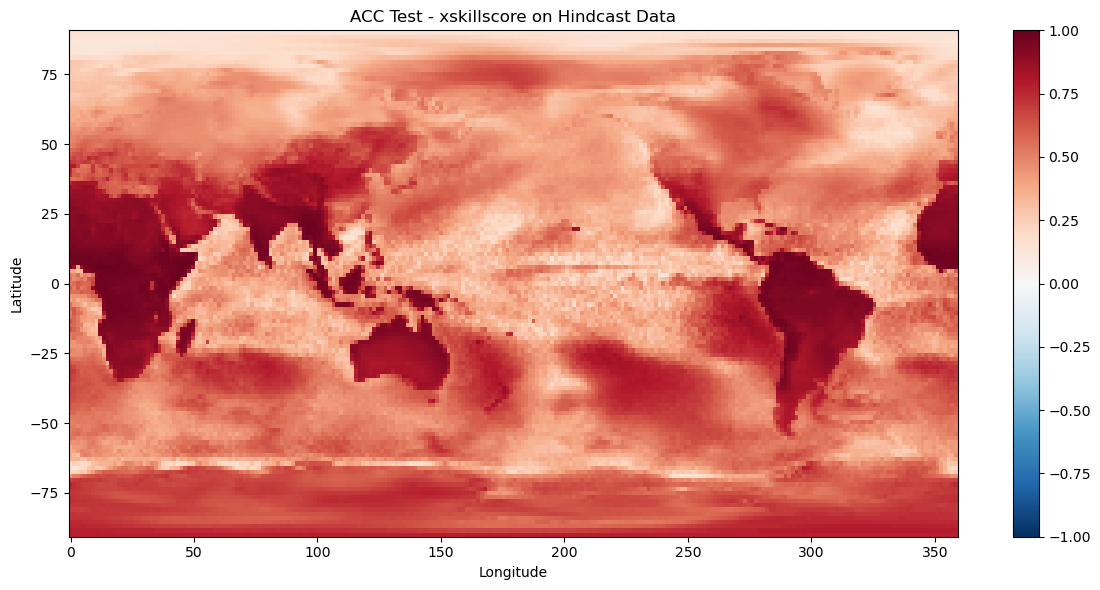


TEST COMPLETE - xskillscore works with the hindcast structure!


In [24]:
# ======================================================================
# Quick visualization
# ======================================================================
fig, ax = plt.subplots(figsize=(12, 6))
acc_mean = acc.mean(dim="ensemble")
im = acc_mean.plot(ax=ax, cmap="RdBu_r", vmin=-1, vmax=1, add_colorbar=True)
ax.set_title("ACC Test - xskillscore on Hindcast Data")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

print("\nTEST COMPLETE - xskillscore works with the hindcast structure!")

In [25]:
# ======================================================================
# Verify ALL ensemble members at one point
# ======================================================================
from xskillscore.core.deterministic import anomaly_correlation_coefficient

def manual_acc_point_members(obs_ts, fct_ts, clim_ts=None):
    """
    Compute manual ACC for each forecast member at a single grid point.
    
    Parameters
    ----------
    obs_ts : xr.DataArray (time,)
        Observations at one grid point
    fct_ts : xr.DataArray (ensemble, time)
        All ensemble members at one grid point
    clim_ts : xr.DataArray (time,) or None
        Climatology at one grid point
    
    Returns
    -------
    np.ndarray shape (ensemble,)
        ACC for each member
    """
    obs = obs_ts.values              # (T,)
    fct = fct_ts.values              # (M, T)
    
    if clim_ts is not None:
        clim = clim_ts.values        # (T,)
        obs_anom = obs - clim        # (T,)
        fct_anom = fct - clim[None,:]  # broadcast → (M, T)
    else:
        obs_anom = obs - obs.mean()
        fct_anom = fct - fct.mean(axis=1, keepdims=True)
    
    # numerator: dot(obs_anom, fct_anom_m) for each member
    num = np.sum(fct_anom * obs_anom[None,:], axis=1)
    
    # denominator: ||obs|| * ||fct_m|| for each member
    den = np.sqrt(
        np.sum(obs_anom**2) * np.sum(fct_anom**2, axis=1)
    )
    
    acc = num / den
    
    print("\n--- Manual ACC (All Members) Debug ---")
    print(f"obs anomaly shape: {obs_anom.shape}")
    print(f"fct anomaly shape: {fct_anom.shape}")
    print(f"ACC shape: {acc.shape}")
    print(f"ACC first 5 members: {acc[:5]}")
    
    return acc

# ======================================================================
# Cell 9: Test all ensemble members (CORRECTED)
# ======================================================================
i, j = 60, 120  # Grid point

# Get observations at this point
obs_1pt = obs.isel(lat=i, lon=j)  # Shape: (time,)

# Get ALL ensemble members at this point
fct_all_members = forecast.isel(lat=i, lon=j)  # Shape: (ensemble, time)

# Get climatology - need to broadcast scalar to time dimension
clim_scalar = clim.isel(lat=i, lon=j).values  # Scalar value
clim_1pt = np.full(len(obs_1pt), clim_scalar)  # Broadcast to (time,)

print("\n===== SHAPES =====")
print(f"obs_1pt shape: {obs_1pt.shape}")
print(f"fct_all_members shape: {fct_all_members.shape}")
print(f"clim_1pt shape: {clim_1pt.shape}")  # Should be (time,)
print(f"clim_1pt values (first 3): {clim_1pt[:3]}")  # All same value

# Manual calculation for ALL members
manual_all = manual_acc_point_members(
    obs_1pt, 
    fct_all_members, 
    xr.DataArray(clim_1pt, coords={"time": obs_1pt.time}, dims=["time"])
)

# Library result for ALL members at this point
library_all = acc.isel(lat=i, lon=j).values  # Shape: (ensemble,)

print("\n===== COMPARISON =====")
print(f"Manual ACC (first 5): {manual_all[:5]}")
print(f"Library ACC (first 5): {library_all[:5]}")
print(f"Max difference: {np.max(np.abs(manual_all - library_all)):.6f}")
print(f"Mean difference: {np.mean(np.abs(manual_all - library_all)):.6f}")

# Check if they match
if np.allclose(manual_all, library_all, atol=1e-3):
    print("\nSUCCESS: Manual and library ACC match for ALL members!")
else:
    print("\nDifferences found")


===== SHAPES =====
obs_1pt shape: (201,)
fct_all_members shape: (64, 201)
clim_1pt shape: (201,)
clim_1pt values (first 3): [301.3198 301.3198 301.3198]

--- Manual ACC (All Members) Debug ---
obs anomaly shape: (201,)
fct anomaly shape: (64, 201)
ACC shape: (64,)
ACC first 5 members: [0.46530602 0.50392931 0.45768397 0.34003861 0.24751552]

===== COMPARISON =====
Manual ACC (first 5): [0.46530602 0.50392931 0.45768397 0.34003861 0.24751552]
Library ACC (first 5): [0.46530602 0.50392931 0.45768397 0.34003861 0.24751552]
Max difference: 0.000000
Mean difference: 0.000000

SUCCESS: Manual and library ACC match for ALL members!


Using hindcast data already loaded:

--- FORECAST ---
<xarray.DataArray 't2m' (member: 64, time: 201, lat: 121, lon: 240)> Size: 1GB
dask.array<getitem, shape=(64, 201, 121, 240), dtype=float32, chunksize=(1, 201, 121, 240), chunktype=numpy.ndarray>
Coordinates:
  * member   (member) int64 512B 0 1 2 3 4 5 6 7 8 ... 56 57 58 59 60 61 62 63
  * time     (time) timedelta64[ns] 2kB -2 days +00:00:00 ... 48 days 00:00:00
  * lat      (lat) float64 968B 90.0 88.5 87.0 85.5 ... -85.5 -87.0 -88.5 -90.0
  * lon      (lon) float64 2kB 0.0 1.5 3.0 4.5 6.0 ... 354.0 355.5 357.0 358.5
Shape: (64, 201, 121, 240)

--- OBSERVATIONS ---
<xarray.DataArray 'observations' (time: 201, lat: 121, lon: 240)> Size: 47MB
dask.array<add, shape=(201, 121, 240), dtype=float64, chunksize=(201, 121, 240), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) timedelta64[ns] 2kB -2 days +00:00:00 ... 48 days 00:00:00
  * lat      (lat) float64 968B 90.0 88.5 87.0 85.5 ... -85.5 -87.0 -88.5 -90.0
  * lon      (lo

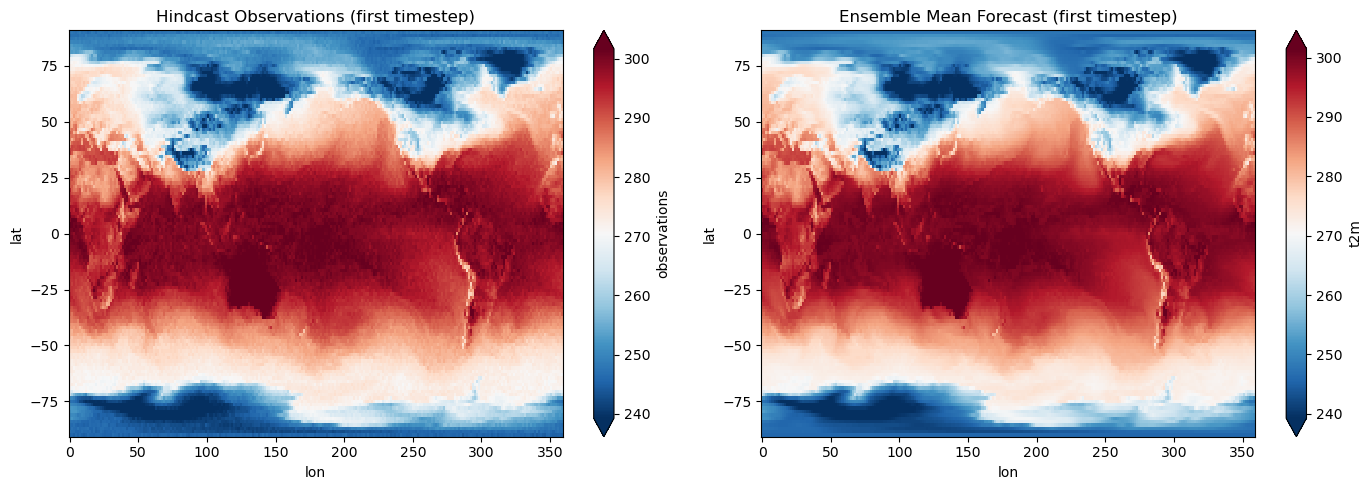


--- Dataset shapes for rank histogram ---
OBS:  (201, 121, 240)  ('time', 'lat', 'lon')
FCT:  (64, 201, 121, 240)  ('member', 'time', 'lat', 'lon')

Data shapes compatible for rank histogram!

Ready for rank histogram analysis:
64 ensemble members
201 timesteps
121 × 240 grid points
Variable: t2m


In [26]:
# ============================================================
# ADAPTED: Use real hindcast data instead of synthetic
# ============================================================
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

print("Using hindcast data already loaded:")
print("=" * 60)

# ============================================================
# 1. Use your existing forecast (already loaded from Zarr)
# ============================================================
# Your forecast shape: (ensemble, time, lat, lon) where time is actually lead_time
fct = forecast.copy()

# Rename ensemble → member (for consistency with example)
if "ensemble" in fct.dims:
    fct = fct.rename({"ensemble": "member"})

print("\n--- FORECAST ---")
print(fct)
print(f"Shape: {fct.shape}")

# ============================================================
# 2. Use your existing observations (dummy for now)
# ============================================================
# You created obs earlier as ensemble mean + noise
obs = obs.copy()  # Use the obs you already created

print("\n--- OBSERVATIONS ---")
print(obs)
print(f"Shape: {obs.shape}")

# ============================================================
# 3. Use your existing climatology (optional for rank histogram)
# ============================================================
# You created clim earlier from day-of-year grouping
# Rank histogram doesn't strictly need climatology, but good to have
if 'clim' in dir():
    print("\n--- CLIMATOLOGY ---")
    print(clim)
    print(f"Shape: {clim.shape}")
else:
    print("\nNo climatology loaded (not needed for rank histogram)")

# ============================================================
# 4. Quick visual check of your data
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot obs at first timestep
obs.isel(time=0).plot(ax=axes[0], cmap="RdBu_r", robust=True)
axes[0].set_title("Hindcast Observations (first timestep)")

# Plot ensemble mean forecast at first timestep
fct.mean(dim="member").isel(time=0).plot(ax=axes[1], cmap="RdBu_r", robust=True)
axes[1].set_title("Ensemble Mean Forecast (first timestep)")

plt.tight_layout()
plt.show()

# ============================================================
# 5. Print dataset shapes (verify compatibility)
# ============================================================
print("\n" + "=" * 60)
print("--- Dataset shapes for rank histogram ---")
print(f"OBS:  {obs.shape}  {obs.dims}")
print(f"FCT:  {fct.shape}  {fct.dims}")

# Check dimensions match
assert "time" in obs.dims and "time" in fct.dims, "Both need 'time' dimension"
assert obs.sizes["lat"] == fct.sizes["lat"], "Lat sizes must match"
assert obs.sizes["lon"] == fct.sizes["lon"], "Lon sizes must match"
assert obs.sizes["time"] == fct.sizes["time"], "Time sizes must match"

print("\nData shapes compatible for rank histogram!")
print("=" * 60)

# ============================================================
# 6. Summary of what we have for rank histogram
# ============================================================
print("\nReady for rank histogram analysis:")
print(f"{fct.sizes['member']} ensemble members")
print(f"{fct.sizes['time']} timesteps")
print(f"{fct.sizes['lat']} × {fct.sizes['lon']} grid points")
print(f"Variable: {fct.name or 'temperature (t2m)'}")

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from xskillscore.core.probabilistic import rank_histogram
from xskillscore.core.viz import plot_rank_histogram_map_cartopy, plot_rank_histogram

fct_loaded = fct.compute()
obs_loaded = obs.compute()



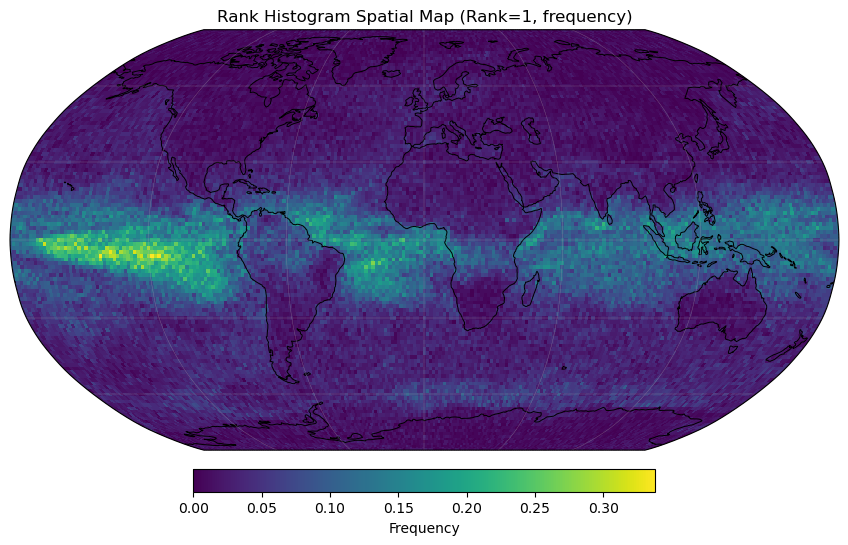

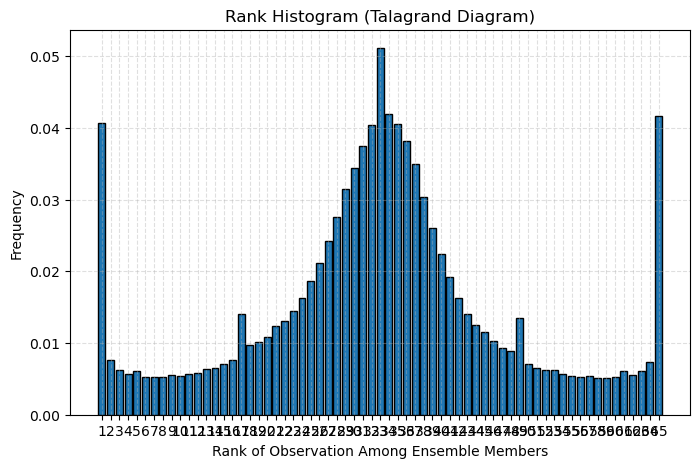

In [28]:
freq_map = plot_rank_histogram_map_cartopy(
    obs_loaded,
    fct_loaded,
    member_dim="member",
    dim="time",
    rank=1,
    normalize=True,
    projection=ccrs.Robinson(),   # You can choose PlateCarree, Mollweide, etc.
)

fg = rank_histogram(obs_loaded, fct_loaded, dim="time", member_dim="member")
plot_rank_histogram(fg)
plt.show()